# Exploring the Battery Storage Environment

This notebook explores the battery storage environment and trains a PPO agent.

In [1]:
import sys
from pathlib import Path

project_root = Path.cwd().parent.parent
sys.path.insert(0, str(project_root / "02_solutions"))

import numpy as np
import matplotlib.pyplot as plt
from battery_env_solution_David import BatteryStorageEnv

## 1. Environment Overview

In [2]:
# Create environment
env = BatteryStorageEnv()

print("=== Battery Storage Environment ===")
print(f"Capacity: {env.capacity} kWh")
print(f"Max charge rate: {env.max_charge_rate} kW")
print(f"Episode length: {env.episode_length} steps")
print(f"Action space: {env.action_space}")
print(f"Observation space: {env.observation_space}")
print(f"\nData split:")
print(f"  Total episodes: {env.n_episodes}")
print(f"  Available episodes: {env._available_episodes}")

=== Battery Storage Environment ===
Capacity: 10.0 kWh
Max charge rate: 5.0 kW
Episode length: 168 steps
Action space: Box(-1.0, 1.0, (1,), float32)
Observation space: Box(0.0, 1.0, (12,), float32)

Data split:
  Total episodes: 156
  Available episodes: (0, 129)


## 2. Running Episodes

In [3]:
def run_episode(env, policy="random", seed=42, thresholds=(0.2, 0.5)):
    """Run a single episode and collect data."""
    obs, info = env.reset(seed=seed)
    
    data = {
        "soc": [info["soc"]],
        "price": [info["price"]],
        "load": [info["load"]],
        "action": [],
        "reward": [],
        "grid_energy": [],
    }
    
    total_reward = 0
    done = False

    threshold_min, threshold_max = thresholds
    
    while not done:
        # Select action based on policy
        if policy == "random":
            action = env.action_space.sample()
        elif policy == "do_nothing":
            action = np.array([0.0], dtype=np.float32)
        elif policy == "simple_heuristic":
            price_norm = obs[2]
            if price_norm < threshold_min:
                action = np.array([1.0], dtype=np.float32)
            elif price_norm > threshold_max:
                action = np.array([-1.0], dtype=np.float32)
            else:
                action = np.array([0.0], dtype=np.float32)
        else:
            action = policy(obs)
        
        # Store old SoC to calculate actual charge power
        old_soc = env.soc
        load = info["load"]
        
        # Take step
        obs, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated
        
        # Calculate ACTUAL charge power from SoC change (not intended action)
        actual_charge_power = env.soc - old_soc
        
        # Calculate ACTUAL grid energy (clamped to 0, can't sell back)
        grid_energy = max(0, load + actual_charge_power)
        
        # Store data
        data["action"].append(action[0])
        data["reward"].append(reward)
        data["grid_energy"].append(grid_energy)
        
        if not done:
            data["soc"].append(info["soc"])
            data["price"].append(info["price"])
            data["load"].append(info["load"])
        
        total_reward += reward
    
    return data, total_reward

## 3. Visualization

In [4]:
def plot_episode(data, title="Episode", xlim=None, price_max=None, thresholds=(0.2, 0.5)):
    """Plot episode data.
    
    Args:
        thresholds: tuple of (charge_threshold, discharge_threshold) in normalized values
        price_max: maximum price for converting normalized thresholds to actual prices
    """
    fig, axes = plt.subplots(5, 1, figsize=(14, 12), sharex=True)
    hours = np.arange(len(data["price"]))
    
    # Price
    axes[0].plot(hours, data["price"], "b-", linewidth=0.8)
    axes[0].set_ylabel("Price (€/kWh)")
    axes[0].set_title(title)
    axes[0].grid(True, alpha=0.3)
    
    # Add threshold lines if provided
    if thresholds and price_max:
        charge_thresh, discharge_thresh = thresholds
        axes[0].axhline(y=charge_thresh * price_max, color="green", linestyle="--", 
                        alpha=0.7, label=f"Charge below (norm < {charge_thresh})")
        axes[0].axhline(y=discharge_thresh * price_max, color="red", linestyle="--", 
                        alpha=0.7, label=f"Discharge above (norm > {discharge_thresh})")
        axes[0].legend(loc="upper right")
    
    # Load and grid energy
    axes[1].plot(hours, data["load"], "orange", linewidth=0.8, label="Load")
    axes[1].plot(hours, data["grid_energy"], "red", linewidth=0.8, alpha=0.7, label="Grid Energy")
    axes[1].axhline(y=0, color="black", linestyle="--", alpha=0.3)
    axes[1].set_ylabel("Energy (kWh)")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    # State of charge
    axes[2].plot(hours, data["soc"], "g-", linewidth=0.8)
    axes[2].axhline(y=10, color="red", linestyle="--", alpha=0.5, label="Capacity")
    axes[2].set_ylabel("SoC (kWh)")
    axes[2].set_ylim(0, 11)
    axes[2].legend()
    axes[2].grid(True, alpha=0.3)
    
    # Actions
    colors = ["green" if a > 0 else "red" if a < 0 else "gray" for a in data["action"]]
    axes[3].bar(hours, data["action"], color=colors, alpha=0.7, width=1.0)
    axes[3].set_ylabel("Action")
    axes[3].set_ylim(-1.1, 1.1)
    axes[3].axhline(y=0, color="black", linestyle="-", alpha=0.3)
    axes[3].grid(True, alpha=0.3)
    
    # Accumulated savings (baseline cost - actual cost)
    baseline_cost = np.cumsum(np.array(data["price"]) * np.array(data["load"]))
    actual_cost = np.cumsum(-np.array(data["reward"]))
    savings = baseline_cost - actual_cost
    axes[4].plot(hours, savings, "g-", linewidth=0.8)
    axes[4].axhline(y=0, color="black", linestyle="--", alpha=0.3)
    axes[4].fill_between(hours, 0, savings, where=savings >= 0, alpha=0.2, color="green")
    axes[4].fill_between(hours, 0, savings, where=savings < 0, alpha=0.2, color="red")
    axes[4].set_ylabel("Savings (€)")
    axes[4].set_xlabel("Hour")
    axes[4].grid(True, alpha=0.3)
    
    # Day markers as x-axis ticks
    day_ticks = np.arange(0, len(data["price"]), 24)
    axes[4].set_xticks(day_ticks)
    axes[4].set_xticklabels([f"Day {i//24 + 1}" for i in day_ticks], rotation=45)
    
    if xlim:
        for ax in axes:
            ax.set_xlim(xlim)
    
    plt.tight_layout()
    return fig

## 4. Policy Comparison

In [5]:
policies = ["do_nothing", "random", "simple_heuristic"]

print("Policy Comparison (10 episodes each):")
print("=" * 50)

for policy in policies:
    rewards = [run_episode(env, policy=policy, seed=seed)[1] for seed in range(10)]
    if policy == "do_nothing":
        baseline_cost = - np.mean(rewards)
    cost_mean = -np.mean(rewards)
    cost_std = np.std(rewards)
    print(f"{policy:20s}: {cost_mean:7.2f} ± {cost_std:5.2f} € (saved cost: {baseline_cost - cost_mean:6.2f} €)")

Policy Comparison (10 episodes each):
do_nothing          :   35.82 ±  1.66 € (saved cost:   0.00 €)
random              :   54.06 ±  4.09 € (saved cost: -18.24 €)
simple_heuristic    :   35.11 ±  1.89 € (saved cost:   0.71 €)


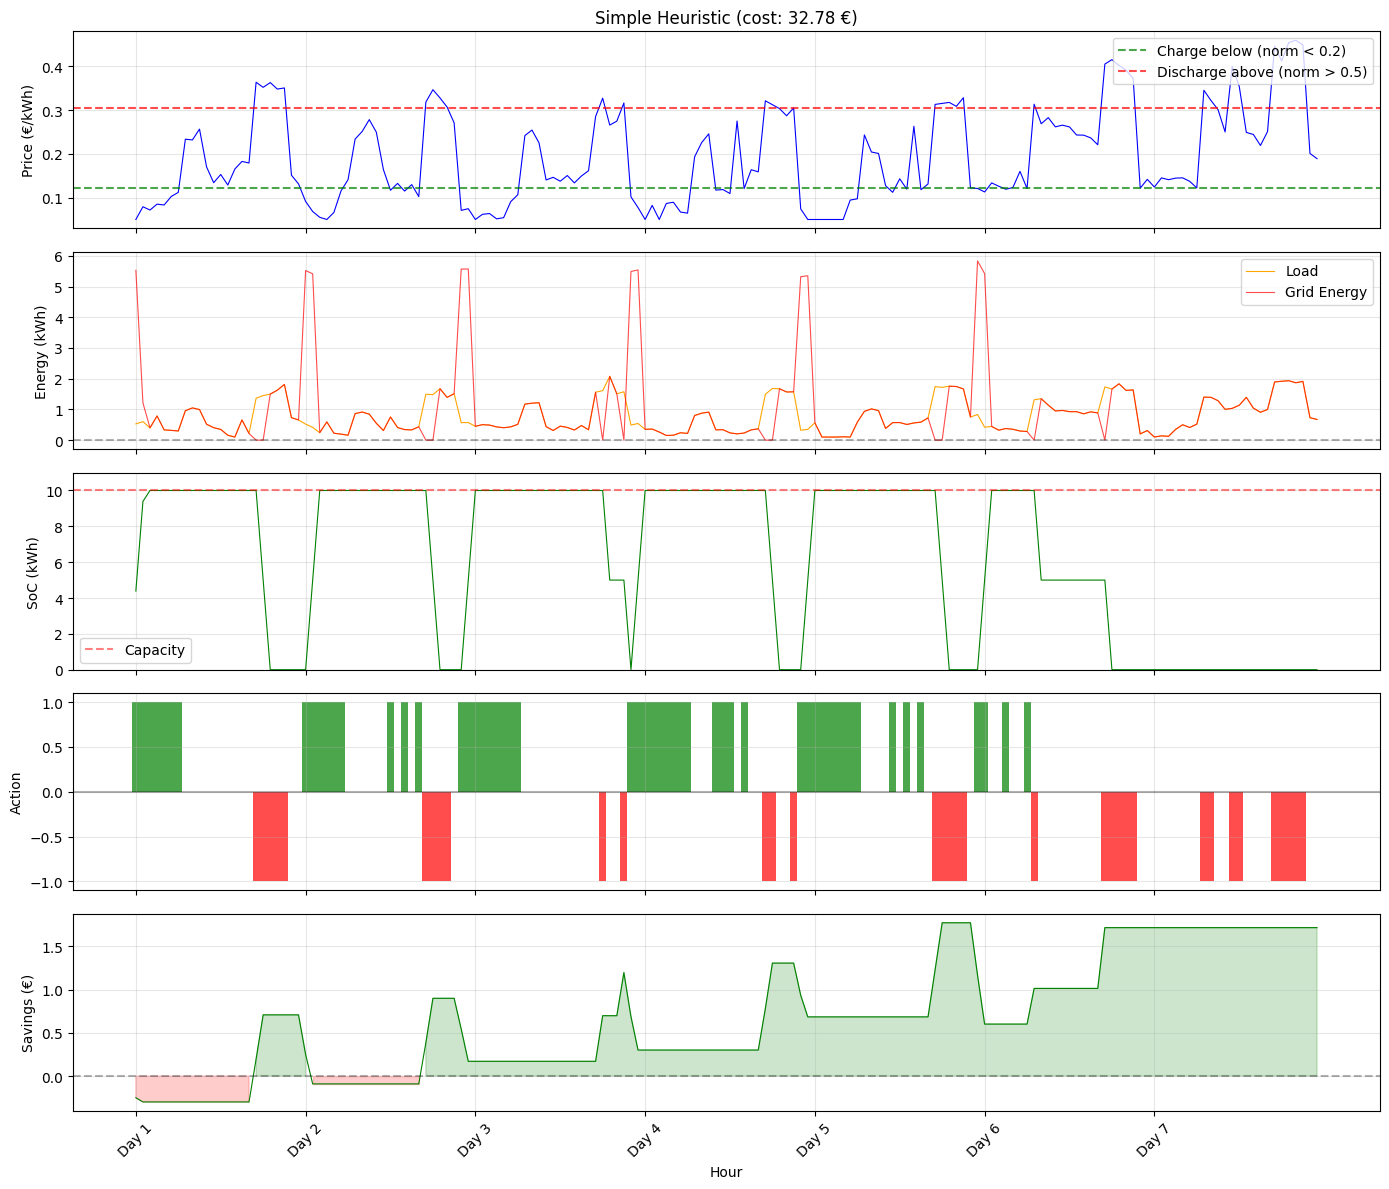

In [6]:
# Visualize simple heuristic with threshold lines
# Thresholds: charge when price_norm < 0.3, discharge when price_norm > 0.5
data, reward = run_episode(env, policy="simple_heuristic", seed=42)
fig = plot_episode(
    data, 
    f"Simple Heuristic (cost: {-reward:.2f} €)",
    price_max=env.price_max,
)
plt.show()

## 5. Train PPO Agent

In [7]:
from stable_baselines3 import PPO
from stable_baselines3.common.env_util import make_vec_env
from stable_baselines3.common.evaluation import evaluate_policy

# Use train/eval split to avoid data leakage
def make_train_env():
    return BatteryStorageEnv(split="train")

def make_eval_env():
    return BatteryStorageEnv(split="eval")

train_env = make_vec_env(make_train_env, n_envs=4)
eval_env = make_eval_env()

# Show split info
train_info = BatteryStorageEnv(split="train")
print(f"Train episodes: {train_info._available_episodes}")
print(f"Eval episodes:  {eval_env._available_episodes}")
train_info.close()

model = PPO("MlpPolicy", train_env, verbose=0)

print("\nBefore training (on eval set):")
mean_before, std_before = evaluate_policy(model, eval_env, n_eval_episodes=10)
print(f"  Reward: {mean_before:.2f} ± {std_before:.2f}")

Train episodes: (0, 129)
Eval episodes:  (129, 156)

Before training (on eval set):
  Reward: -35.81 ± 2.19


/Users/david.goll/Documents/projects/workshop-rl2-implementation/.venv/lib/python3.13/site-packages/stable_baselines3/common/evaluation.py:70: UserWarning: Evaluation environment is not wrapped with a ``Monitor`` wrapper. This may result in reporting modified episode lengths and rewards, if other wrappers happen to modify these. Consider wrapping environment first with ``Monitor`` wrapper.
  warnings.warn(


In [8]:
total_timesteps = int(2e5)
print(f"Training ({total_timesteps//1000}k steps)...")
model.learn(total_timesteps=total_timesteps, progress_bar=True)

Output()

Training (200k steps)...


In [9]:
print("\nAfter training:")
mean_after, std_after = evaluate_policy(model, eval_env, n_eval_episodes=100)
print(f"  Reward: {mean_after:.2f} ± {std_after:.2f}")
print(f"  Improvement: {mean_after - mean_before:.2f}")


After training:
  Reward: -34.06 ± 2.09
  Improvement: 1.75


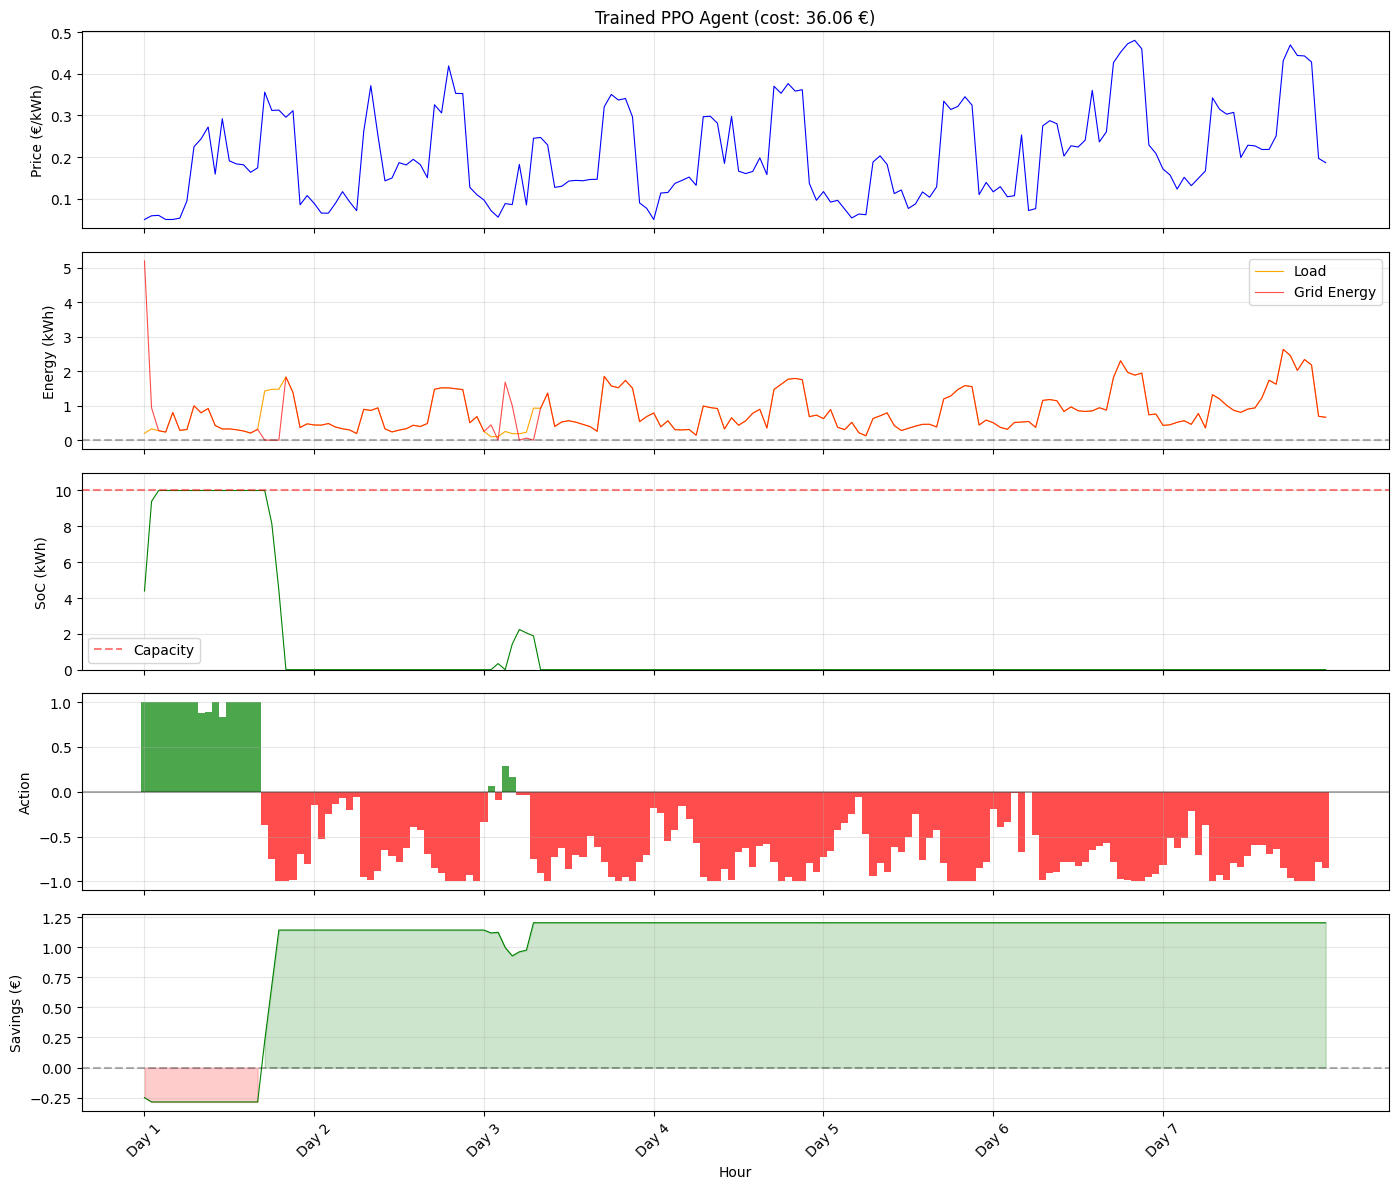

In [10]:
data_ppo, reward_ppo = run_episode(eval_env, policy=lambda obs: model.predict(obs, deterministic=True)[0], seed=42)
fig = plot_episode(data_ppo, f"Trained PPO Agent (cost: {-reward_ppo:.2f} €)")
plt.show()

In [11]:
eval_env_compare = make_eval_env()

# Run all policies over 100 episodes
policies = {
    "No battery": "do_nothing",
    "Heuristic": "simple_heuristic",
    "PPO": lambda obs: model.predict(obs, deterministic=True)[0],
}

results = {}
for name, policy in policies.items():
    rewards = [run_episode(eval_env_compare, policy=policy, seed=seed)[1] for seed in range(100)]
    results[name] = {"cost": -np.mean(rewards), "std": np.std(rewards)}

baseline_cost = results["No battery"]["cost"]

print("Final Comparison (100 eval episodes)")
print("=" * 60)
print(f"{'Policy':<15} {'Avg Cost (€)':>15} {'Savings (€)':>15} {'Savings (%)':>15}")
print("-" * 60)
for name, r in results.items():
    savings = baseline_cost - r["cost"]
    pct = 100 * savings / baseline_cost if baseline_cost > 0 else 0
    print(f"{name:<15} {r['cost']:>11.2f} ± {r['std']:.2f} {savings:>+11.2f} {pct:>+14.1f}%")

eval_env_compare.close()

Final Comparison (100 eval episodes)
Policy             Avg Cost (€)     Savings (€)     Savings (%)
------------------------------------------------------------
No battery            35.97 ± 1.64       +0.00           +0.0%
Heuristic             35.43 ± 1.51       +0.54           +1.5%
PPO                   34.12 ± 1.74       +1.85           +5.2%


In [12]:
# Cleanup
train_env.close()
eval_env.close()
eval_env_compare.close()